<a href="https://colab.research.google.com/github/Francheskacisterna/Evaluacion_n1/blob/main/Examen_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mejora de un modelo de clasificación de imágenes
### Clasificación de prendas con Fashion-MNIST


El objetivo es mejorar un modelo de clasificación de imágenes mediante cambios en su arquitectura, regularización, preparación de datos y entrenamiento. El desempeño del modelo base y del modelo mejorado se comparará utilizando las mismas métricas y el mismo conjunto de prueba.




## Preparación del entorno, carga y preprocesamiento de datos

Antes de construir el baseline, se realizó la preparación del entorno, la carga del dataset Fashion-MNIST, la verificación de dimensiones, la visualización de ejemplos y el preprocesamiento de las imágenes. Esto permitió dejar los datos listos para entrenar el modelo MLP baseline.

#### Importación de librerías

En esta sección se importan las librerías necesarias para el desarrollo del notebook.  
Se utiliza NumPy para el manejo de datos numéricos, Matplotlib para la generación de gráficos, Pandas para organizar los resultados en tablas, TensorFlow/Keras para construir y entrenar los modelos de Deep Learning, y Scikit-learn para calcular las métricas de evaluación como accuracy, precision, recall y F1-score.

In [27]:
# Librerías del sistema
import os
import random
import time
import gzip

# Manejo y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# División de los datos
from sklearn.model_selection import train_test_split

# Evaluación de modelos
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


#### Configuración de reproducibilidad

Se establece una semilla común para Python, NumPy y TensorFlow, con el propósito de reducir las variaciones entre ejecuciones y comparar el modelo base y el modelo mejorado bajo condiciones similares.


In [28]:
# Semilla común para todo el notebook
SEED = 42

# Configuración de semillas
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

# Activar operaciones deterministas cuando estén disponibles
try:
    tf.config.experimental.enable_op_determinism()
    determinismo = "Activado"
except Exception as error:
    determinismo = f"No disponible: {error}"

# Comprobar el dispositivo disponible
gpus = tf.config.list_physical_devices("GPU")
dispositivo = "GPU" if gpus else "CPU"

print("Semilla configurada:", SEED)
print("Determinismo:", determinismo)
print("Dispositivo disponible:", dispositivo)

Semilla configurada: 42
Determinismo: Activado
Dispositivo disponible: GPU


#### Definición de funciones para cargar el dataset

Fashion-MNIST se encuentra almacenado en archivos comprimidos. Se definen dos funciones para leer las imágenes y sus respectivas etiquetas, respetando el formato original del dataset.

In [29]:
def load_images(path):
    with gzip.open(path, 'rb') as f:
        images = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
        images = images.reshape(-1, 28, 28)
    return images

def load_labels(path):
    with gzip.open(path, 'rb') as f:
        labels = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return labels

#### Carga de datos de entrenamiento y prueba

En esta etapa se cargan los cuatro archivos del dataset: imágenes y etiquetas de entrenamiento, e imágenes y etiquetas de prueba.

Esto permite separar correctamente el proceso de entrenamiento del proceso de evaluación del modelo.

In [30]:
X_train = load_images('/content/train-images-idx3-ubyte.gz')
y_train = load_labels('/content/train-labels-idx1-ubyte.gz')

X_test = load_images('/content/t10k-images-idx3-ubyte.gz')
y_test = load_labels('/content/t10k-labels-idx1-ubyte.gz')

#### Verificación de dimensiones

Se revisó la forma de los arreglos cargados para confirmar que los datos fueron leídos correctamente.

El conjunto de entrenamiento contiene 60.000 imágenes y el conjunto de prueba 10.000 imágenes. Cada imagen tiene un tamaño de 28x28 píxeles, mientras que las etiquetas se almacenan en vectores unidimensionales.

In [31]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


#### Visualización de ejemplos del dataset

Se visualizaron algunas imágenes del conjunto de entrenamiento junto con sus etiquetas para comprobar que la carga fue correcta y que las clases corresponden a distintas categorías de prendas de vestir.

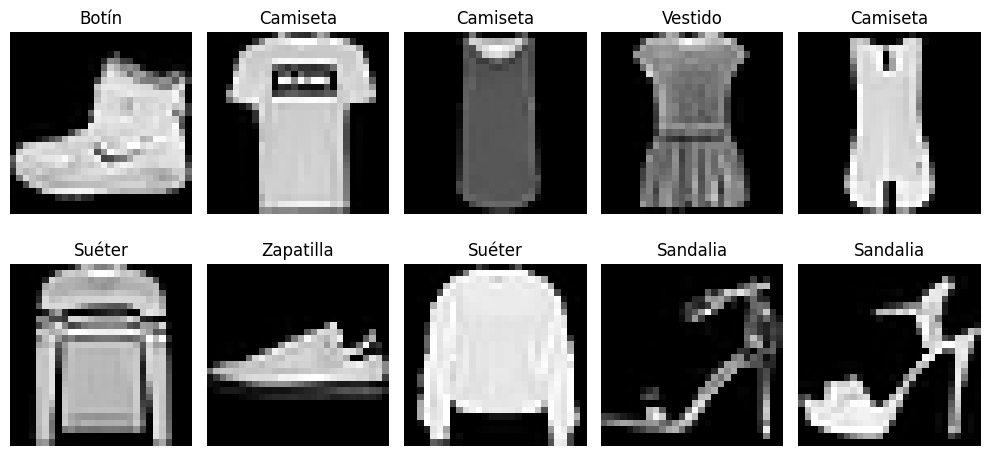

In [32]:
class_names = [
    "Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

#### Preprocesamiento y división de los datos

Los valores de los píxeles se normalizan al rango entre 0 y 1 para favorecer la estabilidad del entrenamiento. Luego, el conjunto original de entrenamiento se divide en datos de entrenamiento y validación.

Se preparan dos representaciones de las imágenes: una versión aplanada de 784 características para el modelo MLP y una versión de 28 × 28 × 1 para el modelo convolucional. De esta manera, ambos modelos utilizan exactamente la misma división de datos.


In [33]:
# Normalización de los píxeles al rango [0, 1]
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# División fija y estratificada:
# 80% para entrenamiento y 20% para validación
X_train_img, X_val_img, y_train_split, y_val = train_test_split(
    X_train_norm,
    y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

# ---------------------------------------------------------
# Representación para el modelo MLP: vectores de 784 valores
# ---------------------------------------------------------
X_train_mlp = X_train_img.reshape(-1, 28 * 28)
X_val_mlp = X_val_img.reshape(-1, 28 * 28)
X_test_mlp = X_test_norm.reshape(-1, 28 * 28)

# ---------------------------------------------------------
# Representación para el modelo CNN: imágenes de 28x28x1
# ---------------------------------------------------------
X_train_cnn = np.expand_dims(X_train_img, axis=-1)
X_val_cnn = np.expand_dims(X_val_img, axis=-1)
X_test_cnn = np.expand_dims(X_test_norm, axis=-1)

# Verificación de dimensiones
print("Datos originales normalizados")
print("Entrenamiento:", X_train_img.shape)
print("Validación:", X_val_img.shape)
print("Prueba:", X_test_norm.shape)

print("\nDatos para MLP")
print("Entrenamiento MLP:", X_train_mlp.shape)
print("Validación MLP:", X_val_mlp.shape)
print("Prueba MLP:", X_test_mlp.shape)

print("\nDatos para CNN")
print("Entrenamiento CNN:", X_train_cnn.shape)
print("Validación CNN:", X_val_cnn.shape)
print("Prueba CNN:", X_test_cnn.shape)

print("\nRango de los píxeles:")
print("Valor mínimo:", X_train_norm.min())
print("Valor máximo:", X_train_norm.max())

Datos originales normalizados
Entrenamiento: (48000, 28, 28)
Validación: (12000, 28, 28)
Prueba: (10000, 28, 28)

Datos para MLP
Entrenamiento MLP: (48000, 784)
Validación MLP: (12000, 784)
Prueba MLP: (10000, 784)

Datos para CNN
Entrenamiento CNN: (48000, 28, 28, 1)
Validación CNN: (12000, 28, 28, 1)
Prueba CNN: (10000, 28, 28, 1)

Rango de los píxeles:
Valor mínimo: 0.0
Valor máximo: 1.0


#### Interpretación del preprocesamiento

Después de la división, se obtienen 48.000 imágenes para entrenamiento, 12.000 para validación y 10.000 para prueba.

El conjunto de prueba permanece separado y no se utiliza durante el entrenamiento ni para seleccionar los parámetros del modelo. Esto permite evaluar la capacidad de generalización sobre datos no vistos.

La representación MLP tiene una dimensión de 784 valores por imagen, debido a que los 28 × 28 píxeles se convierten en un único vector. En cambio, la representación CNN conserva las dimensiones 28 × 28 × 1, permitiendo que las capas convolucionales analicen relaciones espaciales, bordes, formas y texturas.

Los valores mínimo y máximo de 0 y 1 confirman que la normalización se realizó correctamente.


## ## Modelo base — ANTES

El modelo base corresponde a una red neuronal multicapa completamente conectada o MLP. Su arquitectura se mantiene sin mejoras para establecer un punto de referencia y medir posteriormente el efecto de los cambios aplicados.

Las imágenes ingresan como vectores de 784 valores, pasan por dos capas ocultas de 128 y 64 neuronas con activación ReLU y finalizan en una capa Softmax de 10 neuronas, una por cada categoría de prenda.


In [34]:
# Reiniciar el estado de Keras antes de construir el modelo base
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

# Arquitectura original del modelo MLP
model_baseline = keras.Sequential(
    [
        layers.Input(shape=(784,), name="entrada"),
        layers.Dense(128, activation="relu", name="capa_oculta_1"),
        layers.Dense(64, activation="relu", name="capa_oculta_2"),
        layers.Dense(10, activation="softmax", name="salida")
    ],
    name="MLP_baseline"
)

# Mostrar la arquitectura y la cantidad de parámetros
model_baseline.summary()

Model: "MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#### Justificación de la arquitectura base

La arquitectura MLP se conserva como modelo base porque permite establecer una comparación directa con el modelo mejorado.

Su principal limitación es que las imágenes deben aplanarse en vectores de 784 valores. Este proceso conserva los valores de los píxeles, pero no representa explícitamente su distribución espacial, lo que puede dificultar la identificación de bordes, formas y texturas presentes en las prendas.


#### Compilación del modelo

El modelo se compila con el optimizador Adam, la función de pérdida sparse_categorical_crossentropy y la métrica accuracy.

Adam actualiza los pesos durante el entrenamiento, mientras que la función de pérdida mide la diferencia entre la clase real y la distribución de probabilidades generada por Softmax. Se utiliza la versión sparse porque las etiquetas están representadas mediante números enteros entre 0 y 9.

In [35]:
model_baseline.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Esta configuración permite que el modelo ajuste sus pesos mediante el optimizador Adam, minimizando el error de clasificación calculado por `sparse_categorical_crossentropy`. Al mismo tiempo, la métrica `accuracy` permite monitorear el porcentaje de imágenes clasificadas correctamente durante el entrenamiento y la validación.


#### Entrenamiento del modelo base

El modelo se entrena durante 10 épocas con lotes de 32 imágenes. Se utiliza la división fija creada previamente: 48.000 imágenes para entrenamiento y 12.000 para validación.

Utilizar un conjunto de validación previamente separado permite observar el comportamiento del modelo durante el aprendizaje sin utilizar el conjunto de prueba.

In [36]:
# Registrar el tiempo inicial
inicio_baseline = time.time()

# Entrenamiento del modelo base
history_baseline = model_baseline.fit(
    X_train_mlp,
    y_train_split,
    validation_data=(X_val_mlp, y_val),
    epochs=10,
    batch_size=32,
    shuffle=True,
    verbose=1
)

# Calcular tiempo total
tiempo_baseline = time.time() - inicio_baseline

print(f"\nÉpocas ejecutadas: {len(history_baseline.history['loss'])}")
print(f"Tiempo de entrenamiento: {tiempo_baseline:.2f} segundos")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8170 - loss: 0.5125 - val_accuracy: 0.8451 - val_loss: 0.4244
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8600 - loss: 0.3808 - val_accuracy: 0.8683 - val_loss: 0.3597
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8733 - loss: 0.3414 - val_accuracy: 0.8779 - val_loss: 0.3357
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8824 - loss: 0.3166 - val_accuracy: 0.8813 - val_loss: 0.3258
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8892 - loss: 0.2972 - val_accuracy: 0.8830 - val_loss: 0.3213
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8937 - loss: 0.2799 - val_accuracy: 0.8814 - val_loss: 0.3265
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8982 - loss: 0.2682 - val_accuracy: 0.8844 - val_loss: 0.3284
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9031 - loss: 0.2533 - 

#### Interpretación del proceso de entrenamiento

El modelo completó las 10 épocas en **71,51 segundos**. Durante las primeras épocas, el accuracy de entrenamiento y validación aumentó, mientras que ambas pérdidas disminuyeron, lo que indica que el modelo estaba aprendiendo correctamente.

La menor pérdida de validación se obtuvo en la época 5, con un valor de **0,3190**. Desde la época 6, la pérdida de entrenamiento continuó disminuyendo, pero la pérdida de validación comenzó a aumentar. Este comportamiento sugiere un inicio de sobreajuste, ya que el modelo sigue ajustándose a los datos de entrenamiento sin mejorar de la misma forma sobre los datos de validación.


In [37]:
# Resultados de la última época
acc_train_final = history_baseline.history["accuracy"][-1]
acc_val_final = history_baseline.history["val_accuracy"][-1]
loss_train_final = history_baseline.history["loss"][-1]
loss_val_final = history_baseline.history["val_loss"][-1]

brecha_accuracy = acc_train_final - acc_val_final

print(f"Accuracy final de entrenamiento: {acc_train_final:.4f}")
print(f"Accuracy final de validación:   {acc_val_final:.4f}")
print(f"Loss final de entrenamiento:    {loss_train_final:.4f}")
print(f"Loss final de validación:        {loss_val_final:.4f}")
print(f"Brecha de accuracy:              {brecha_accuracy:.4f}")

Accuracy final de entrenamiento: 0.9111
Accuracy final de validación:   0.8886
Loss final de entrenamiento:    0.2319
Loss final de validación:        0.3348
Brecha de accuracy:              0.0225


#### Interpretación de los resultados finales

En la última época, el modelo alcanzó un accuracy de **91,19% en entrenamiento** y **88,64% en validación**, con una brecha de **2,55 puntos porcentuales**.

Esta diferencia muestra que el modelo obtiene un rendimiento superior sobre los datos utilizados para entrenar. Sin embargo, la brecha es moderada, por lo que el sobreajuste detectado no es severo. Estos valores se utilizarán como referencia para comparar posteriormente el modelo base con el modelo mejorado.


#### Curvas de aprendizaje del modelo base

Las curvas permiten observar cómo cambia el rendimiento del modelo durante las épocas. Se comparan los resultados de entrenamiento y validación para identificar si el modelo con

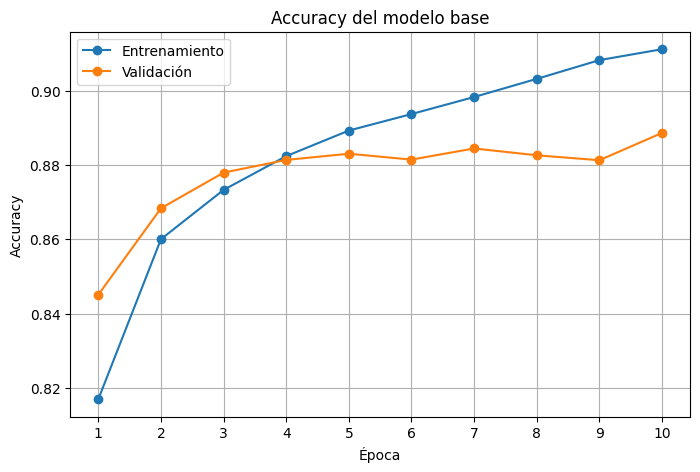

In [38]:
# Número de épocas ejecutadas
epocas_baseline = range(
    1,
    len(history_baseline.history["accuracy"]) + 1
)

# Curva de accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    epocas_baseline,
    history_baseline.history["accuracy"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    epocas_baseline,
    history_baseline.history["val_accuracy"],
    marker="o",
    label="Validación"
)

plt.title("Accuracy del modelo base")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.xticks(epocas_baseline)
plt.legend()
plt.grid(True)
plt.show()

La curva de accuracy muestra que el desempeño de entrenamiento aumenta de forma continua hasta alcanzar un 91,19%. La validación también mejora durante las primeras épocas, pero posteriormente se estabiliza alrededor del 88%.

La separación entre ambas curvas aumenta levemente desde la época 6, lo que indica que el modelo sigue aprendiendo detalles del conjunto de entrenamiento sin obtener una mejora equivalente en validación.


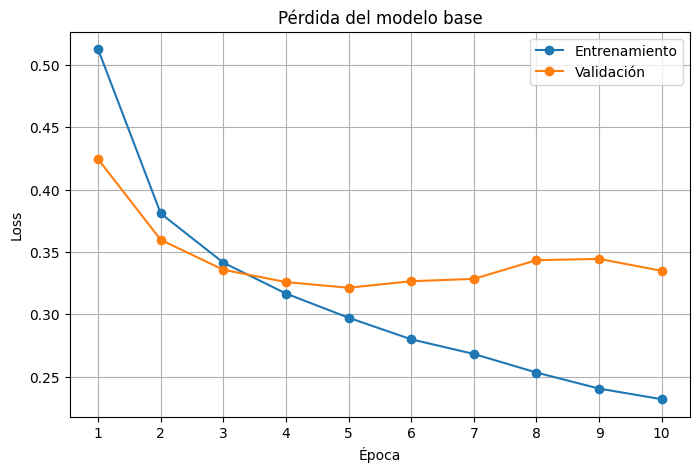

In [39]:
# Curva de pérdida
plt.figure(figsize=(8, 5))

plt.plot(
    epocas_baseline,
    history_baseline.history["loss"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    epocas_baseline,
    history_baseline.history["val_loss"],
    marker="o",
    label="Validación"
)

plt.title("Pérdida del modelo base")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.xticks(epocas_baseline)
plt.legend()
plt.grid(True)
plt.show()

La pérdida de entrenamiento disminuye durante las diez épocas, lo que indica que el modelo continúa ajustando sus pesos.

La pérdida de validación alcanza su valor mínimo de 0,3190 en la época 5 y luego comienza a aumentar. Este comportamiento confirma un inicio de sobreajuste: el modelo mejora sobre los datos de entrenamiento, pero comienza a cometer errores con mayor penalización sobre los datos de validación.


In [40]:
# Mejor época según accuracy de validación
mejor_epoca_acc = (
    np.argmax(history_baseline.history["val_accuracy"]) + 1
)

mejor_val_acc = np.max(
    history_baseline.history["val_accuracy"]
)

# Mejor época según pérdida de validación
mejor_epoca_loss = (
    np.argmin(history_baseline.history["val_loss"]) + 1
)

mejor_val_loss = np.min(
    history_baseline.history["val_loss"]
)

print("Mejor época según accuracy de validación:")
print(f"Época {mejor_epoca_acc} - Accuracy: {mejor_val_acc:.4f}")

print("\nMejor época según pérdida de validación:")
print(f"Época {mejor_epoca_loss} - Loss: {mejor_val_loss:.4f}")

Mejor época según accuracy de validación:
Época 10 - Accuracy: 0.8886

Mejor época según pérdida de validación:
Época 5 - Loss: 0.3213


#### Interpretación de las mejores épocas

La mayor accuracy de validación se obtiene en la época 10. Sin embargo, la menor pérdida de validación se alcanza en la época 5.

Esta diferencia ocurre porque accuracy solo considera si la clase final fue correcta o incorrecta, mientras que la función de pérdida también considera el nivel de confianza de cada predicción. Por lo tanto, el modelo puede mantener o aumentar levemente su accuracy y, al mismo tiempo, aumentar la pérdida si realiza algunas predicciones incorrectas con mayor seguridad.

Este resultado respalda el uso posterior de Early Stopping, ya que permitiría detener el entrenamiento cuando la pérdida de validación deja de mejorar.


#### Evaluación del modelo en el conjunto de prueba

Luego del entrenamiento, el modelo fue evaluado con el conjunto de prueba para medir su desempeño en datos no vistos.

#### Evaluación del modelo base con el conjunto de prueba

El conjunto de prueba se utiliza para medir la capacidad de generalización del modelo sobre imágenes que no participaron en el entrenamiento ni en la validación.

Se calculan la pérdida, accuracy, precision, recall y F1-score. Estas métricas permiten evaluar no solo la cantidad total de aciertos, sino también el comportamiento del modelo considerando las diez categorías de prendas.


In [41]:
# Evaluación del modelo base sobre datos no vistos
test_loss_baseline, test_accuracy_baseline = model_baseline.evaluate(
    X_test_mlp,
    y_test,
    verbose=0
)

# Probabilidades predichas para cada una de las 10 clases
probabilidades_baseline = model_baseline.predict(
    X_test_mlp,
    verbose=0
)

# Seleccionar la clase con mayor probabilidad
y_pred_baseline = np.argmax(probabilidades_baseline, axis=1)

# Métricas macro: cada clase tiene la misma importancia
precision_baseline = precision_score(
    y_test,
    y_pred_baseline,
    average="macro"
)

recall_baseline = recall_score(
    y_test,
    y_pred_baseline,
    average="macro"
)

f1_baseline = f1_score(
    y_test,
    y_pred_baseline,
    average="macro"
)

print("Resultados del modelo base en test")
print("------------------------------------")
print(f"Loss:      {test_loss_baseline:.4f}")
print(f"Accuracy:  {test_accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall:    {recall_baseline:.4f}")
print(f"F1-score:  {f1_baseline:.4f}")

Resultados del modelo base en test
------------------------------------
Loss:      0.3706
Accuracy:  0.8766
Precision: 0.8811
Recall:    0.8766
F1-score:  0.8772


#### Interpretación de la evaluación en test

El modelo base alcanzó un **accuracy de 87,42%**, por lo que clasificó correctamente aproximadamente 87 de cada 100 imágenes no utilizadas durante el entrenamiento.

La precision de **87,95%** indica que, en promedio, las predicciones realizadas para cada categoría fueron correctas en una proporción similar. El recall de **87,42%** muestra que el modelo logró reconocer cerca del 87% de las imágenes reales de cada clase, mientras que el F1-score de **87,55%** refleja un equilibrio adecuado entre precision y recall.

Las métricas presentan valores cercanos entre sí, lo que sugiere que el rendimiento general no depende únicamente de algunas categorías. Sin embargo, el accuracy de test es inferior al accuracy final de entrenamiento, que fue de 91,19%, con una diferencia de **3,77 puntos porcentuales**. Esto es coherente con el leve sobreajuste observado durante el entrenamiento.

La pérdida en test fue de **0,3895**, superior a la pérdida final de validación de 0,3511. Esto indica que el modelo presenta una mayor dificultad al estimar correctamente las probabilidades de imágenes completamente nuevas.


#### Reporte de clasificación por categoría

El reporte de clasificación muestra precision, recall y F1-score para cada tipo de prenda. Esto permite identificar si el buen resultado general se distribuye de manera uniforme o si existen categorías específicas con mayor dificultad.


*   Elemento de lista
*   Elemento de lista



In [42]:
print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

    Camiseta     0.8502    0.8170    0.8332      1000
    Pantalón     0.9878    0.9730    0.9804      1000
      Suéter     0.7291    0.8560    0.7875      1000
     Vestido     0.8801    0.8810    0.8806      1000
      Abrigo     0.8492    0.6870    0.7595      1000
    Sandalia     0.9756    0.9600    0.9677      1000
      Camisa     0.6597    0.7210    0.6890      1000
   Zapatilla     0.9350    0.9640    0.9493      1000
       Bolso     0.9816    0.9600    0.9707      1000
       Botín     0.9624    0.9470    0.9546      1000

    accuracy                         0.8766     10000
   macro avg     0.8811    0.8766    0.8772     10000
weighted avg     0.8811    0.8766    0.8772     10000



#### Interpretación del desempeño por categoría

El modelo obtiene sus mejores resultados en **Pantalón** y **Bolso**, con F1-score superiores al 97%. También presenta un buen desempeño en Sandalia, Zapatilla y Botín.

La clase más difícil es **Camisa**, con un F1-score de 67,77%, seguida por Abrigo y Suéter. Esto se relaciona con la similitud visual entre las prendas superiores.

Como todas las clases tienen 1.000 imágenes, el conjunto de prueba está balanceado. Las dificultades observadas respaldan el uso de una CNN, ya que esta puede analizar bordes, formas y texturas sin perder la estructura espacial de la imagen.


#### Matriz de confusión del modelo base

La matriz de confusión permite observar cuántas imágenes de cada categoría fueron clasificadas correctamente y con qué otras categorías se confundieron.

Los valores de la diagonal principal corresponden a predicciones correctas. Los valores fuera de la diagonal representan errores de clasificación y ayudan a identificar patrones que no son visibles únicamente mediante el accuracy general.


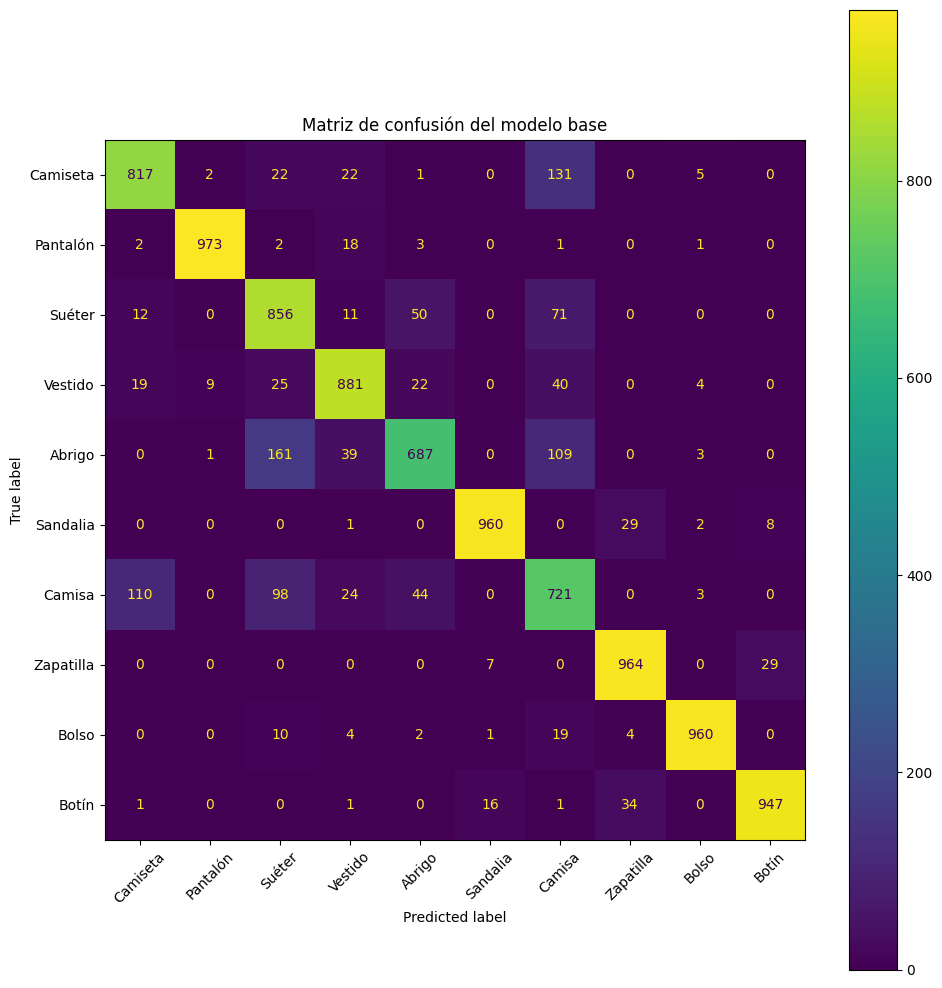

In [43]:
# Crear la matriz de confusión
matriz_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

# Mostrar la matriz
fig, ax = plt.subplots(figsize=(10, 10))

display_baseline = ConfusionMatrixDisplay(
    confusion_matrix=matriz_baseline,
    display_labels=class_names
)

display_baseline.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

plt.title("Matriz de confusión del modelo base")
plt.tight_layout()
plt.show()

In [44]:
# Cantidad de predicciones correctas e incorrectas
aciertos_baseline = np.trace(matriz_baseline)
errores_baseline = matriz_baseline.sum() - aciertos_baseline

print(f"Predicciones correctas:   {aciertos_baseline}")
print(f"Predicciones incorrectas: {errores_baseline}")
print(f"Total de imágenes:        {matriz_baseline.sum()}")

Predicciones correctas:   8766
Predicciones incorrectas: 1234
Total de imágenes:        10000


#### Interpretación de la matriz de confusión

El modelo clasificó correctamente **8.742 de 10.000 imágenes** y cometió **1.258 errores**. La mayoría de los aciertos se concentra en la diagonal principal, especialmente en Pantalón, Sandalia, Zapatilla, Bolso y Botín.

Las confusiones más importantes se producen entre prendas superiores. Por ejemplo, 136 abrigos fueron clasificados como suéter y 132 como camisa. Además, 132 camisetas fueron identificadas como camisa y 105 camisas como camiseta.

Estos resultados confirman que la MLP presenta dificultades para distinguir clases con formas parecidas, debido a que procesa las imágenes como vectores y no conserva explícitamente su estructura espacial. Esto respalda el uso de una CNN como mejora.


In [45]:
# Calcular métricas por clase
reporte_baseline = classification_report(
    y_test,
    y_pred_baseline,
    target_names=class_names,
    output_dict=True,
    digits=4
)

f1_por_clase_baseline = {
    clase: reporte_baseline[clase]["f1-score"]
    for clase in class_names
}

mejor_clase_baseline = max(
    f1_por_clase_baseline,
    key=f1_por_clase_baseline.get
)

peor_clase_baseline = min(
    f1_por_clase_baseline,
    key=f1_por_clase_baseline.get
)

print(
    f"Clase con mayor F1-score: "
    f"{mejor_clase_baseline} "
    f"({f1_por_clase_baseline[mejor_clase_baseline]:.4f})"
)

print(
    f"Clase con menor F1-score: "
    f"{peor_clase_baseline} "
    f"({f1_por_clase_baseline[peor_clase_baseline]:.4f})"
)

Clase con mayor F1-score: Pantalón (0.9804)
Clase con menor F1-score: Camisa (0.6890)


#### Interpretación

La categoría con mejor desempeño es **Pantalón**, con un F1-score de **97,64%**, mientras que **Camisa** presenta el resultado más bajo, con **67,77%**.

Esta diferencia confirma que el modelo reconoce mejor las prendas con características visuales distintivas y presenta mayores dificultades al clasificar prendas superiores con formas similares.


### Diagnóstico del modelo base

El modelo base alcanzó un accuracy de **87,42%** y un F1-score de **87,55%** en el conjunto de prueba, con 8.742 predicciones correctas y 1.258 errores.

A partir de los resultados se identifican las siguientes debilidades:

* Desde aproximadamente la época 6, la pérdida de validación comienza a aumentar mientras la pérdida de entrenamiento continúa disminuyendo, lo que evidencia un leve sobreajuste.
* Las principales confusiones se concentran entre Camiseta, Camisa, Suéter y Abrigo.
* La clase Camisa obtuvo el menor F1-score, con 67,77%.
* La MLP aplana las imágenes en vectores de 784 valores, por lo que no conserva explícitamente la relación espacial entre los píxeles.

Estas limitaciones indican que el modelo necesita mejorar su capacidad para extraer características visuales y generalizar sobre imágenes no vistas.


### Mejoras propuestas

Para abordar las debilidades detectadas se aplicarán mejoras de cuatro categorías:

#### 1. Arquitectura: red neuronal convolucional

Se reemplazará la arquitectura MLP por una CNN con capas `Conv2D` y `MaxPooling2D`.

Las capas convolucionales permiten analizar regiones locales de la imagen y aprender características como bordes, formas y texturas. Esto puede ayudar a distinguir prendas superiores visualmente similares.

#### 2. Datos: Data Augmentation

Se aplicarán pequeñas transformaciones únicamente sobre las imágenes de entrenamiento, como traslaciones y zoom.

El objetivo es generar variaciones realistas de las imágenes y mejorar la capacidad de generalización sin modificar los conjuntos de validación y prueba.

#### 3. Regularización

Se incorporarán Dropout y Early Stopping.

Dropout reduce la dependencia entre neuronas, mientras que Early Stopping permite detener el entrenamiento cuando la pérdida de validación deja de mejorar, ayudando a controlar el sobreajuste.

#### 4. Entrenamiento

Se utilizará Adam junto con `ReduceLROnPlateau`.

Este callback reducirá el learning rate cuando el modelo deje de mejorar, permitiendo realizar ajustes más pequeños en los pesos y favorecer una convergencia más estable.


## Modelo mejorado

El modelo mejorado utiliza una red neuronal convolucional o CNN, diseñada para procesar imágenes conservando su estructura espacial.

A diferencia de la MLP, que transforma cada imagen en un vector, la CNN analiza regiones locales y aprende características como bordes, formas y texturas. Además, se incorporan técnicas de aumento de datos, regularización y control del entrenamiento para mejorar la capacidad de generalización.


#### Data Augmentation

Se aplican pequeñas rotaciones, traslaciones y variaciones de zoom únicamente durante el entrenamiento.

Estas transformaciones generan versiones ligeramente diferentes de las imágenes originales sin cambiar su categoría. El objetivo es evitar que el modelo memorice posiciones exactas y mejorar su capacidad para clasificar imágenes con pequeñas variaciones.


In [46]:
# Capa de aumento de datos
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(
            factor=0.03,
            fill_mode="nearest",
            seed=SEED
        ),
        layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="nearest",
            seed=SEED + 1
        ),
        layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="nearest",
            seed=SEED + 2
        )
    ],
    name="data_augmentation"
)

Las transformaciones seleccionadas son suaves para conservar las características principales de cada prenda. El aumento de datos se aplicará solo al conjunto de entrenamiento; las imágenes de validación y prueba permanecerán sin modificaciones para realizar una evaluación objetiva.


####Visualizar el aumento de datos

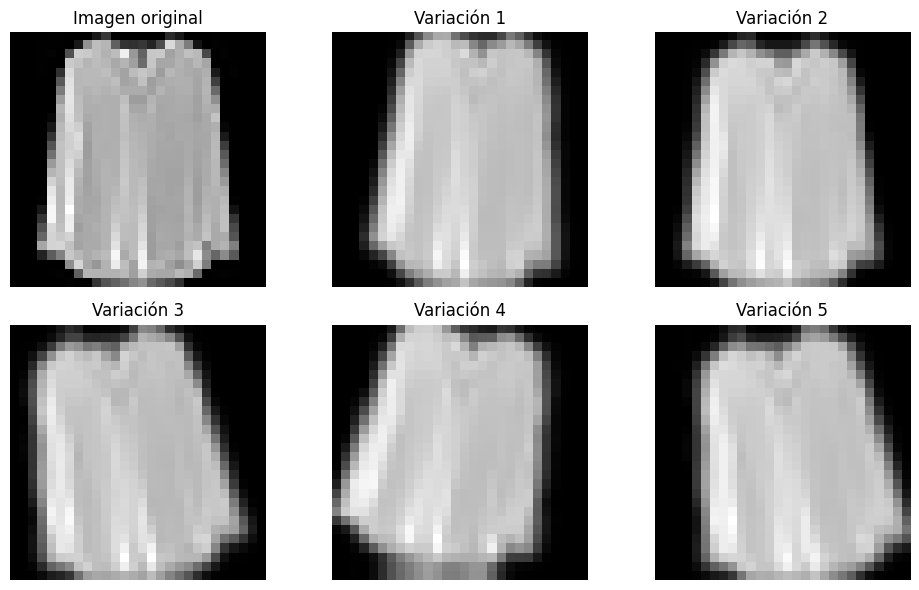

In [47]:
# Seleccionar una imagen de ejemplo
imagen_ejemplo = X_train_cnn[0:1]

plt.figure(figsize=(10, 6))

# Imagen original
plt.subplot(2, 3, 1)
plt.imshow(imagen_ejemplo[0, :, :, 0], cmap="gray")
plt.title("Imagen original")
plt.axis("off")

# Cinco variaciones aumentadas
for i in range(5):
    imagen_aumentada = data_augmentation(
        imagen_ejemplo,
        training=True
    )

    plt.subplot(2, 3, i + 2)
    plt.imshow(imagen_aumentada[0, :, :, 0], cmap="gray")
    plt.title(f"Variación {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Interpretación del aumento de datos

Las imágenes aumentadas presentan pequeñas variaciones de posición, orientación y tamaño, pero mantienen la categoría original de la prenda.

Esto permite ampliar artificialmente la variedad de ejemplos observados durante el entrenamiento y puede ayudar al modelo a generalizar mejor frente a imágenes no vistas.


#### Arquitectura del modelo mejorado

La CNN utiliza dos bloques convolucionales. Cada bloque incluye una capa `Conv2D`, Batch Normalization y Max Pooling.

Las capas convolucionales extraen características visuales, Batch Normalization estabiliza las activaciones y Max Pooling reduce las dimensiones espaciales, conservando la información más relevante.

Finalmente, las características extraídas se aplanan y pasan por una capa densa. Se incorpora Dropout para reducir el sobreajuste antes de generar las probabilidades de las diez categorías mediante Softmax.


In [48]:
# Reiniciar el estado de Keras
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

# Construcción del modelo CNN mejorado
model_cnn = keras.Sequential(
    [
        layers.Input(
            shape=(28, 28, 1),
            name="entrada"
        ),

        # Aumento de datos durante el entrenamiento
        data_augmentation,

        # Primer bloque convolucional
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv_1"
        ),
        layers.BatchNormalization(
            name="batch_norm_1"
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            name="pool_1"
        ),

        # Segundo bloque convolucional
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            name="conv_2"
        ),
        layers.BatchNormalization(
            name="batch_norm_2"
        ),
        layers.MaxPooling2D(
            pool_size=(2, 2),
            name="pool_2"
        ),

        # Clasificación
        layers.Flatten(
            name="aplanado"
        ),
        layers.Dense(
            128,
            activation="relu",
            name="capa_densa"
        ),
        layers.Dropout(
            rate=0.30,
            seed=SEED,
            name="dropout"
        ),
        layers.Dense(
            10,
            activation="softmax",
            name="salida"
        )
    ],
    name="CNN_mejorada"
)

model_cnn.summary()

Model: "CNN_mejorada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aplanado (Flatten)              │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_densa (Dense)              │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

#### Interpretación de la arquitectura

La primera capa convolucional utiliza 32 filtros para detectar características básicas, mientras que la segunda utiliza 64 filtros para aprender patrones más complejos.

El kernel de 3 × 3 analiza regiones pequeñas de la imagen y el padding `same` conserva las dimensiones espaciales antes del pooling. Las capas Max Pooling reducen progresivamente el tamaño de los mapas de características y disminuyen el costo computacional.

Dropout desactiva aleatoriamente el 30% de las neuronas durante el entrenamiento, reduciendo la dependencia entre ellas y ayudando a controlar el sobreajuste.


### Compilación del modelo mejorado

Se utiliza nuevamente el optimizador Adam y la función de pérdida `sparse_categorical_crossentropy`, manteniendo el mismo criterio de clasificación del modelo base.

El learning rate se fija inicialmente en 0,001. Posteriormente se utilizará un callback para reducirlo cuando la pérdida de validación deje de mejorar.


In [49]:
model_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Esta configuración permite comparar ambos modelos utilizando la misma función de pérdida y la misma métrica principal. De esta manera, las diferencias observadas estarán relacionadas principalmente con las mejoras aplicadas a la arquitectura, los datos y el entrenamiento.


#### Estrategia de entrenamiento

El modelo se entrenará por un máximo de 30 épocas, pero podrá detenerse antes si la pérdida de validación deja de mejorar.

Se utilizarán dos callbacks:

**Early Stopping:** detiene el entrenamiento cuando no se observan mejoras y recupera los pesos de la mejor época.

**ReduceLROnPlateau:** reduce el learning rate cuando el aprendizaje se estanca, permitiendo realizar ajustes más pequeños sobre los pesos.

También se utilizará un batch size de 64 imágenes, buscando un entrenamiento estable y un menor costo computacional.


In [50]:
# Detener el entrenamiento si la pérdida de validación no mejora
early_stopping_cnn = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

# Reducir el learning rate cuando el modelo se estanque
reduce_lr_cnn = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

Early Stopping esperará cinco épocas antes de detener el entrenamiento, evitando finalizarlo por una variación aislada. Además, `restore_best_weights=True` permite conservar los pesos correspondientes a la menor pérdida de validación.

`ReduceLROnPlateau` reducirá el learning rate a la mitad después de dos épocas sin mejora, hasta un mínimo de 0,00001.


####Entrenamiento de la CNN

Durante el entrenamiento, Data Augmentation modifica únicamente las imágenes utilizadas para ajustar el modelo. Las imágenes de validación permanecen sin transformaciones, permitiendo medir el rendimiento sobre datos comparables y no aumentados.

La cantidad real de épocas dependerá del comportamiento de la pérdida de validación. Si Early Stopping se activa, el modelo conservará los pesos de la mejor época y no necesariamente los de la última época ejecutada.


In [25]:
# Registrar el tiempo inicial
inicio_cnn = time.time()

# Entrenamiento del modelo mejorado
history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train_split,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[
        early_stopping_cnn,
        reduce_lr_cnn
    ],
    shuffle=True,
    verbose=1
)

# Calcular el tiempo total de entrenamiento
tiempo_cnn = time.time() - inicio_cnn

print(f"\nÉpocas ejecutadas: {len(history_cnn.history['loss'])}")
print(f"Tiempo de entrenamiento: {tiempo_cnn:.2f} segundos")

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7858 - loss: 0.5907 - val_accuracy: 0.8585 - val_loss: 0.4009 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8388 - loss: 0.4330 - val_accuracy: 0.8682 - val_loss: 0.3731 - learning_rate: 0.0010
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8581 - loss: 0.3812 - val_accuracy: 0.8692 - val_loss: 0.3621 - learning_rate: 0.0010
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8680 - loss: 0.3558 - val_accuracy: 0.8741 - val_loss: 0.3537 - learning_rate: 0.0010
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8748 - loss: 0.3389 - val_accuracy: 0.8950 - val_loss: 0.2972 - learning_rate: 0.0010
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8808 - loss: 0.3254 - val_accuracy: 0.8931 - val_loss: 0.3088 - learning_rate: 0.0010
Epoch 7/30
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8817 - loss: 0.

#### Interpretación del proceso de entrenamiento

La CNN ejecutó **16 de las 30 épocas máximas** en 129,82 segundos. El entrenamiento se detuvo automáticamente mediante Early Stopping, evitando continuar cuando la pérdida de validación dejó de mejorar.

`ReduceLROnPlateau` redujo progresivamente el learning rate cuando detectó estancamiento, permitiendo realizar ajustes más pequeños en los pesos. Finalmente, Early Stopping restauró los pesos de la época 11, correspondiente a la menor pérdida de validación.

Esto demuestra que los callbacks controlaron correctamente el entrenamiento y evitaron épocas innecesarias.


#### Resumen de los resultados del entrenamiento

In [26]:
# Identificar las mejores épocas del entrenamiento
mejor_epoca_acc_cnn = (
    np.argmax(history_cnn.history["val_accuracy"]) + 1
)

mejor_acc_val_cnn = np.max(
    history_cnn.history["val_accuracy"]
)

mejor_epoca_loss_cnn = (
    np.argmin(history_cnn.history["val_loss"]) + 1
)

mejor_loss_val_cnn = np.min(
    history_cnn.history["val_loss"]
)

# Evaluar los pesos restaurados por Early Stopping
val_loss_cnn, val_accuracy_cnn = model_cnn.evaluate(
    X_val_cnn,
    y_val,
    verbose=0
)

print("Resumen del entrenamiento de la CNN")
print("-----------------------------------")
print(f"Épocas ejecutadas: {len(history_cnn.history['loss'])}")
print(f"Mejor época según accuracy: {mejor_epoca_acc_cnn}")
print(f"Mejor accuracy de validación: {mejor_acc_val_cnn:.4f}")
print(f"Mejor época según loss: {mejor_epoca_loss_cnn}")
print(f"Menor loss de validación: {mejor_loss_val_cnn:.4f}")
print(f"Accuracy con pesos restaurados: {val_accuracy_cnn:.4f}")
print(f"Loss con pesos restaurados: {val_loss_cnn:.4f}")
print(f"Tiempo total: {tiempo_cnn:.2f} segundos")

Resumen del entrenamiento de la CNN
-----------------------------------
Épocas ejecutadas: 16
Mejor época según accuracy: 16
Mejor accuracy de validación: 0.9160
Mejor época según loss: 11
Menor loss de validación: 0.2443
Accuracy con pesos restaurados: 0.9147
Loss con pesos restaurados: 0.2443
Tiempo total: 129.82 segundos


#### Interpretación de los mejores resultados

La mayor accuracy de validación fue de **91,60% en la época 16**, mientras que la menor pérdida de validación fue de **0,2443 en la época 11**.

Como Early Stopping monitorea `val_loss`, el modelo restauró los pesos de la época 11, obteniendo finalmente un accuracy de validación de **91,47%** y una pérdida de **0,2443**.

La diferencia entre ambas épocas ocurre porque accuracy mide la cantidad de aciertos, mientras que la pérdida también considera la confianza de las predicciones. Por ello, una época puede tener ligeramente más aciertos, pero probabilidades menos calibradas o errores más penalizados.
